# Google Trends & Financial Market Analysis

## Project Objective

This project analyzes whether Google search interest is associated with
changes in financial and economic indicators.

The analysis focuses on:

1. Tesla search trends vs. Tesla stock price
2. Bitcoin search trends vs. Bitcoin price
3. "Unemployment Benefits" search trends vs. U.S. unemployment rate

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statistical Analysis

## Data Sources

- Google Trends
- Yahoo Finance
- FRED

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_tesla = pd.read_csv('TESLA Search Trend vs Price.csv')
df_btc_price = pd.read_csv('Daily Bitcoin Price.csv')
df_unemployment = pd.read_csv('UE Benefits Search vs UE Rate 2004-19.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
print("Tesla:", df_tesla.shape)
print("Bitcoin Price:", df_btc_price.shape)
print("Unemployment:", df_unemployment.shape)

Tesla: (124, 3)
Bitcoin Price: (2204, 3)
Unemployment: (181, 3)


In [6]:
print("===== TESLA DATA =====")
display(df_tesla.head())

print("\n===== BITCOIN DATA =====")
display(df_btc_price.head())

print("\n===== UNEMPLOYMENT DATA =====")
display(df_unemployment.head())

===== TESLA DATA =====


,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368



===== BITCOIN DATA =====


,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0



===== UNEMPLOYMENT DATA =====


,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


In [7]:
print("===== TESLA COLUMNS =====")
print(df_tesla.columns.tolist())

print("\n===== BITCOIN COLUMNS =====")
print(df_btc_price.columns.tolist())

print("\n===== UNEMPLOYMENT COLUMNS =====")
print(df_unemployment.columns.tolist())

===== TESLA COLUMNS =====
['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE']

===== BITCOIN COLUMNS =====
['DATE', 'CLOSE', 'VOLUME']

===== UNEMPLOYMENT COLUMNS =====
['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE']


In [8]:
print("===== TESLA DATA TYPES =====")
print(df_tesla.dtypes)

print("\n===== BITCOIN DATA TYPES =====")
print(df_btc_price.dtypes)

print("\n===== UNEMPLOYMENT DATA TYPES =====")
print(df_unemployment.dtypes)

===== TESLA DATA TYPES =====
MONTH               object
TSLA_WEB_SEARCH      int64
TSLA_USD_CLOSE     float64
dtype: object

===== BITCOIN DATA TYPES =====
DATE       object
CLOSE     float64
VOLUME    float64
dtype: object

===== UNEMPLOYMENT DATA TYPES =====
MONTH                      object
UE_BENEFITS_WEB_SEARCH      int64
UNRATE                    float64
dtype: object


In [9]:
print("===== MISSING VALUES =====")

print("\nTesla:")
print(df_tesla.isnull().sum())

print("\nBitcoin:")
print(df_btc_price.isnull().sum())

print("\nUnemployment:")
print(df_unemployment.isnull().sum())

===== MISSING VALUES =====

Tesla:
MONTH              0
TSLA_WEB_SEARCH    0
TSLA_USD_CLOSE     0
dtype: int64

Bitcoin:
DATE      0
CLOSE     1
VOLUME    1
dtype: int64

Unemployment:
MONTH                     0
UE_BENEFITS_WEB_SEARCH    0
UNRATE                    0
dtype: int64


In [10]:
print("===== DUPLICATE ROWS =====")

print("Tesla duplicates:", df_tesla.duplicated().sum())
print("Bitcoin duplicates:", df_btc_price.duplicated().sum())
print("Unemployment duplicates:", df_unemployment.duplicated().sum())

===== DUPLICATE ROWS =====
Tesla duplicates: 0
Bitcoin duplicates: 0
Unemployment duplicates: 0


In [11]:
print("===== DATE DATA TYPES =====")

print("Tesla:")
print(df_tesla['MONTH'].dtype)

print("\nBitcoin:")
print(df_btc_price['DATE'].dtype)

print("\nUnemployment:")
print(df_unemployment['MONTH'].dtype)

===== DATE DATA TYPES =====
Tesla:
object

Bitcoin:
object

Unemployment:
object


In [12]:
# Convert date columns to datetime

df_tesla['MONTH'] = pd.to_datetime(df_tesla['MONTH'])
df_btc_price['DATE'] = pd.to_datetime(df_btc_price['DATE'])
df_unemployment['MONTH'] = pd.to_datetime(df_unemployment['MONTH'])

print("Date conversion completed!")

Date conversion completed!


In [13]:
print("Tesla:", df_tesla['MONTH'].dtype)
print("Bitcoin:", df_btc_price['DATE'].dtype)
print("Unemployment:", df_unemployment['MONTH'].dtype)

Tesla: datetime64[ns]
Bitcoin: datetime64[ns]
Unemployment: datetime64[ns]


In [14]:
df_tesla = df_tesla.sort_values('MONTH').reset_index(drop=True)

df_btc_price = df_btc_price.sort_values('DATE').reset_index(drop=True)

df_unemployment = df_unemployment.sort_values('MONTH').reset_index(drop=True)

print("All datasets sorted chronologically!")

All datasets sorted chronologically!


In [15]:
df_btc_price[df_btc_price['CLOSE'].isnull() | df_btc_price['VOLUME'].isnull()]

,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


In [16]:
df_btc_price = df_btc_price.dropna(subset=['CLOSE', 'VOLUME']).reset_index(drop=True)

print("Missing values after cleaning:")
print(df_btc_price.isnull().sum())

Missing values after cleaning:
DATE      0
CLOSE     0
VOLUME    0
dtype: int64


In [17]:
print("Bitcoin negative values:")
print("Negative CLOSE:", (df_btc_price['CLOSE'] < 0).sum())
print("Negative VOLUME:", (df_btc_price['VOLUME'] < 0).sum())

print("\nTesla negative values:")
print("Negative search:", (df_tesla['TSLA_WEB_SEARCH'] < 0).sum())
print("Negative price:", (df_tesla['TSLA_USD_CLOSE'] < 0).sum())

print("\nUnemployment negative values:")
print("Negative search:", (df_unemployment['UE_BENEFITS_WEB_SEARCH'] < 0).sum())
print("Negative unemployment rate:", (df_unemployment['UNRATE'] < 0).sum())

Bitcoin negative values:
Negative CLOSE: 0
Negative VOLUME: 0

Tesla negative values:
Negative search: 0
Negative price: 0

Unemployment negative values:
Negative search: 0
Negative unemployment rate: 0


In [18]:
print("===== FINAL DATA QUALITY CHECK =====")

print("\nTesla:")
print("Rows:", len(df_tesla))
print("Missing:", df_tesla.isnull().sum().sum())
print("Duplicates:", df_tesla.duplicated().sum())

print("\nBitcoin:")
print("Rows:", len(df_btc_price))
print("Missing:", df_btc_price.isnull().sum().sum())
print("Duplicates:", df_btc_price.duplicated().sum())

print("\nUnemployment:")
print("Rows:", len(df_unemployment))
print("Missing:", df_unemployment.isnull().sum().sum())
print("Duplicates:", df_unemployment.duplicated().sum())

===== FINAL DATA QUALITY CHECK =====

Tesla:
Rows: 124
Missing: 0
Duplicates: 0

Bitcoin:
Rows: 2203
Missing: 0
Duplicates: 0

Unemployment:
Rows: 181
Missing: 0
Duplicates: 0


In [19]:
print("===== TESLA SUMMARY =====")
display(df_tesla.describe())

print("\n===== BITCOIN SUMMARY =====")
display(df_btc_price.describe())

print("\n===== UNEMPLOYMENT SUMMARY =====")
display(df_unemployment.describe())

===== TESLA SUMMARY =====


,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
count,124,124.000000,124.000000
mean,2015-07-17 05:48:23.225806336,8.725806,50.962145
min,2010-06-01 00:00:00,2.000000,3.896000
25%,2012-12-24 06:00:00,3.750000,7.352500
50%,2015-07-16 12:00:00,8.000000,44.653000
75%,2018-02-08 00:00:00,12.000000,58.991999
max,2020-09-01 00:00:00,31.000000,498.320007
std,NaN,5.870332,65.908389



===== BITCOIN SUMMARY =====


,DATE,CLOSE,VOLUME
count,2203,2203.000000,2.203000e+03
mean,2017-09-22 00:35:57.058556672,4429.421245,8.043622e+09
min,2014-09-17 00:00:00,178.102997,5.914570e+06
25%,2016-03-20 12:00:00,433.629502,6.029915e+07
50%,2017-09-22 00:00:00,3637.520020,2.018890e+09
75%,2019-03-26 12:00:00,7997.372803,1.322478e+10
max,2020-09-28 00:00:00,19497.400391,7.415677e+10
std,NaN,4148.150071,1.176529e+10



===== UNEMPLOYMENT SUMMARY =====


,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
count,181,181.000000,181.000000
mean,2011-07-02 01:51:22.872928256,35.110497,6.217680
min,2004-01-01 00:00:00,14.000000,3.700000
25%,2007-10-01 00:00:00,21.000000,4.700000
50%,2011-07-01 00:00:00,26.000000,5.400000
75%,2015-04-01 00:00:00,45.000000,7.800000
max,2019-01-01 00:00:00,100.000000,10.000000
std,NaN,20.484925,1.891859


In [20]:
print("===== DATE RANGES =====")

print(
    "Tesla:",
    df_tesla['MONTH'].min().date(),
    "to",
    df_tesla['MONTH'].max().date()
)

print(
    "Bitcoin:",
    df_btc_price['DATE'].min().date(),
    "to",
    df_btc_price['DATE'].max().date()
)

print(
    "Unemployment:",
    df_unemployment['MONTH'].min().date(),
    "to",
    df_unemployment['MONTH'].max().date()
)

===== DATE RANGES =====
Tesla: 2010-06-01 to 2020-09-01
Bitcoin: 2014-09-17 to 2020-09-28
Unemployment: 2004-01-01 to 2019-01-01


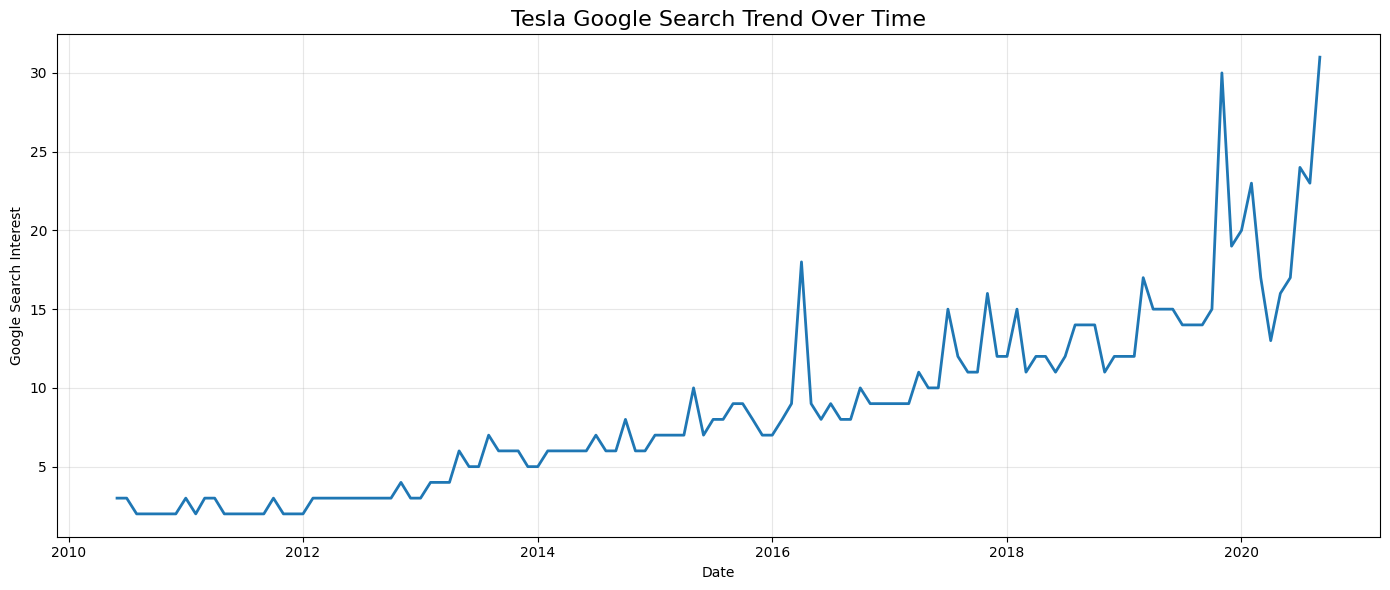

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_WEB_SEARCH'],
    linewidth=2
)

plt.title('Tesla Google Search Trend Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Google Search Interest')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

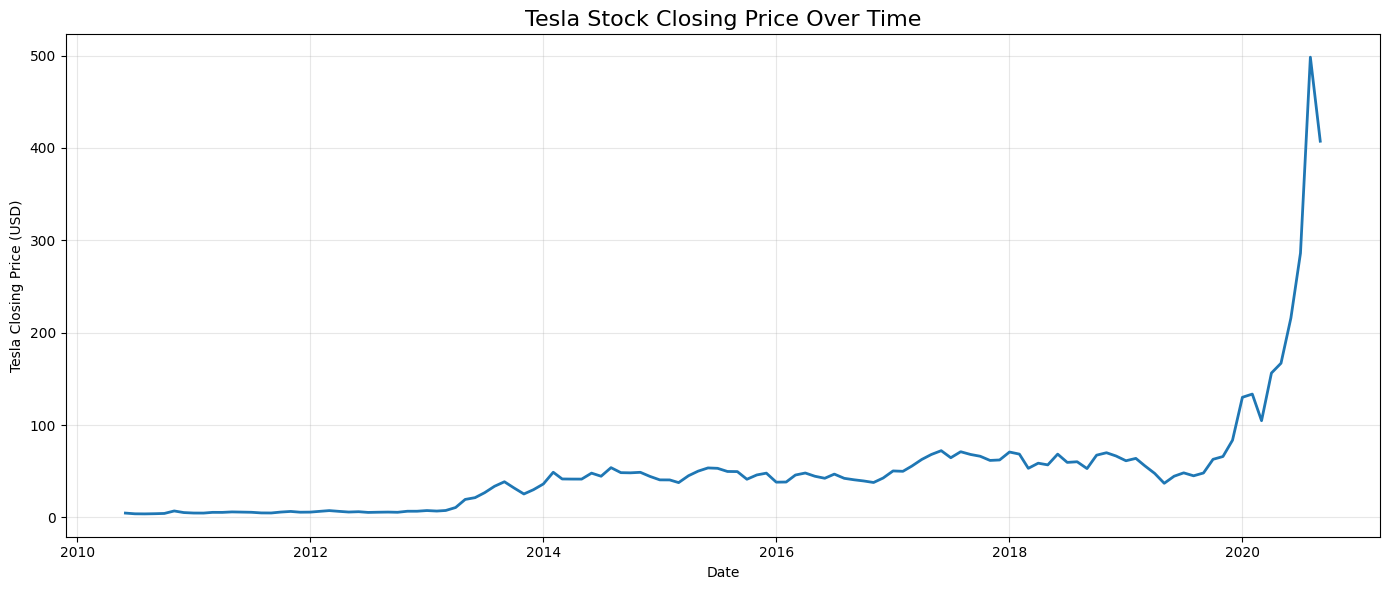

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_USD_CLOSE'],
    linewidth=2
)

plt.title('Tesla Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Tesla Closing Price (USD)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

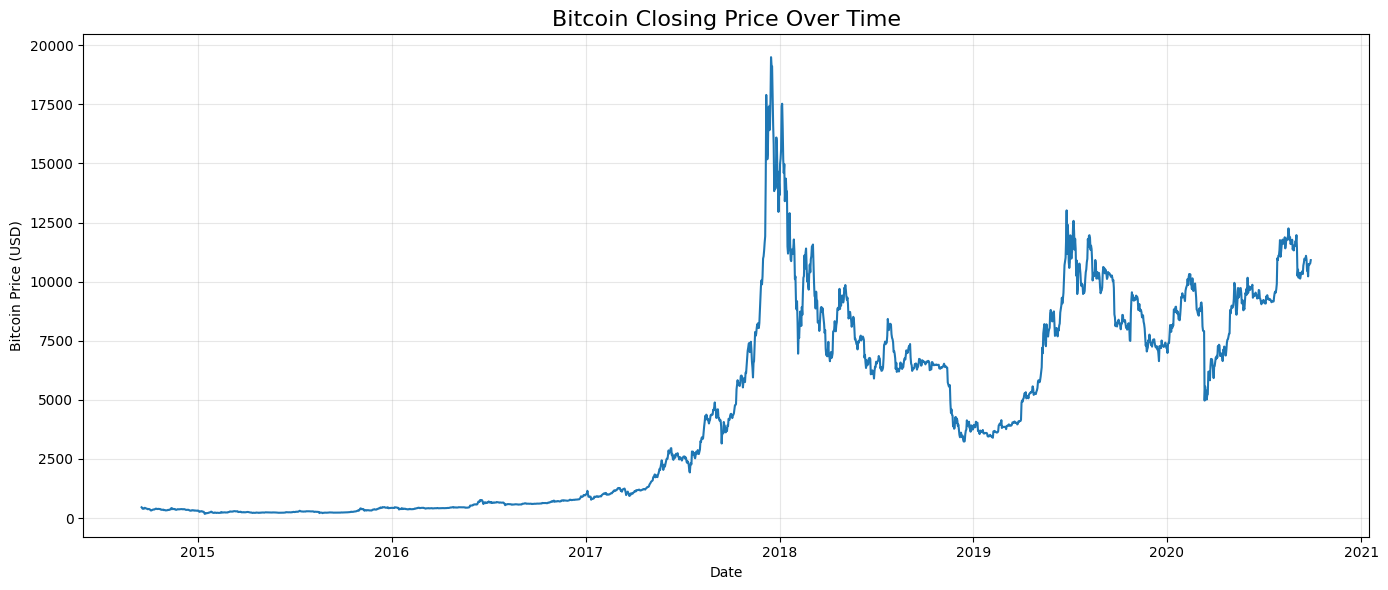

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['CLOSE'],
    linewidth=1.5
)

plt.title('Bitcoin Closing Price Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

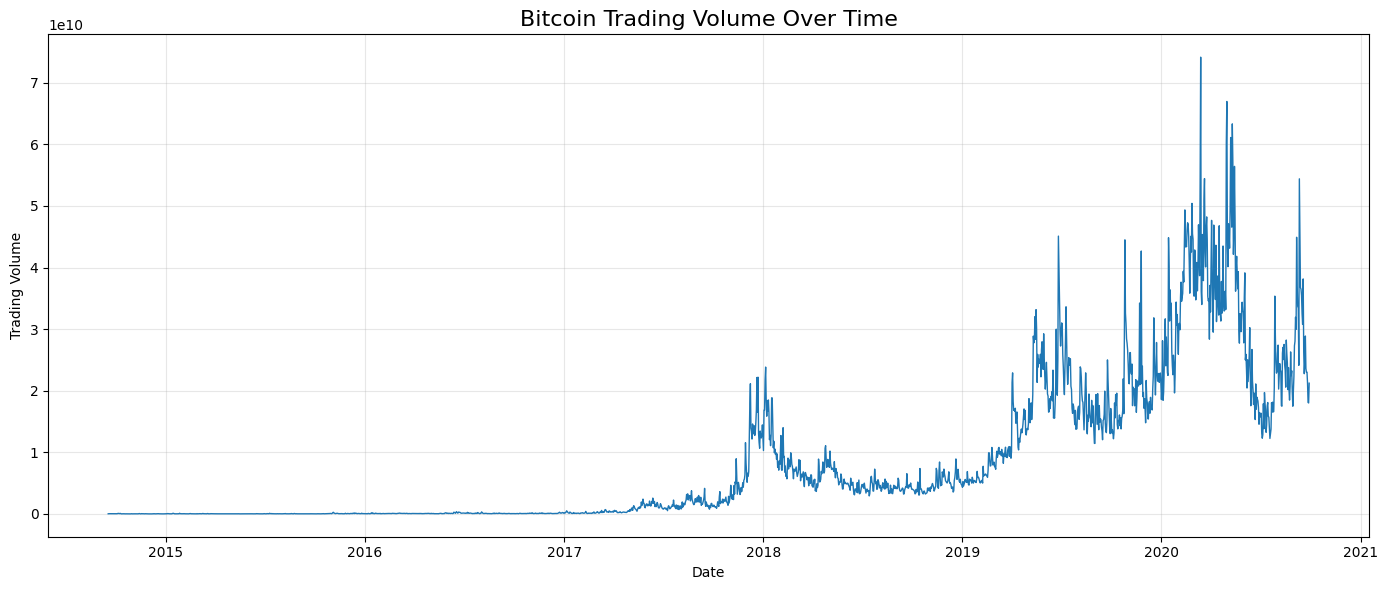

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['VOLUME'],
    linewidth=1
)

plt.title('Bitcoin Trading Volume Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
df_btc_monthly = (
    df_btc_price
    .set_index('DATE')
    .resample('ME')
    .agg({
        'CLOSE': 'mean',
        'VOLUME': 'sum'
    })
    .reset_index()
)

df_btc_monthly.head()

,DATE,CLOSE,VOLUME
0,2014-09-30,407.182428,4.108810e+08
1,2014-10-31,364.148873,9.029944e+08
2,2014-11-30,366.099799,6.597334e+08
3,2014-12-31,341.267871,5.531023e+08
4,2015-01-31,248.782547,1.098812e+09


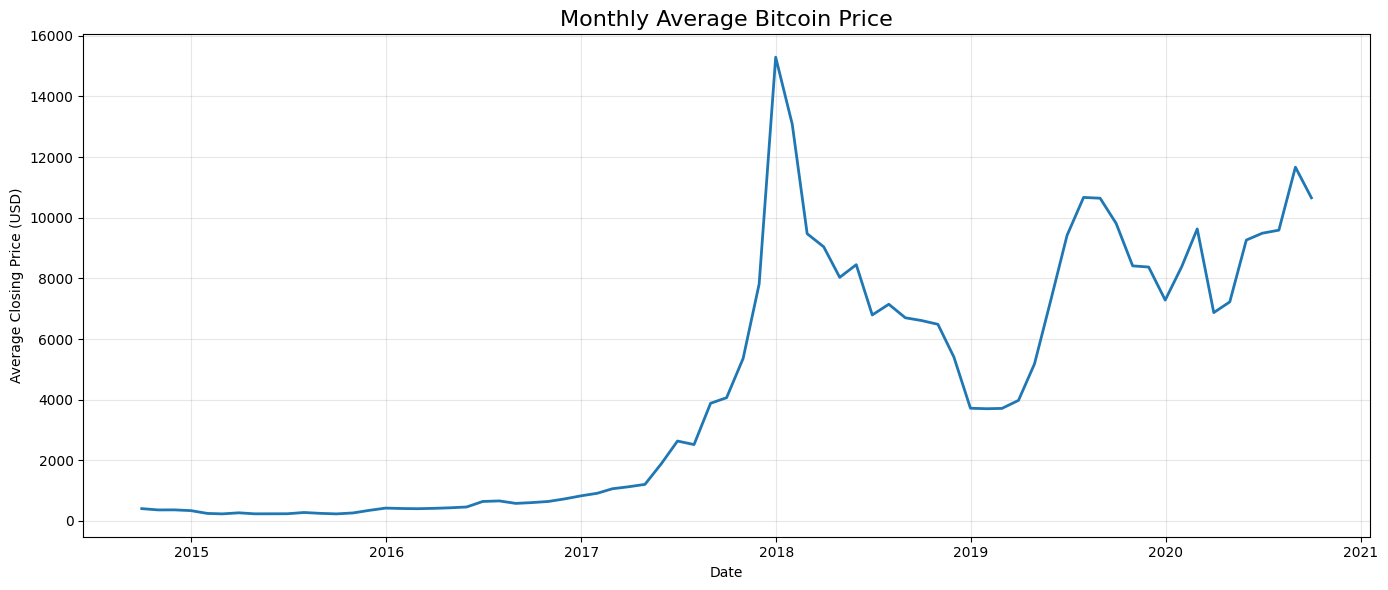

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_monthly['DATE'],
    df_btc_monthly['CLOSE'],
    linewidth=2
)

plt.title('Monthly Average Bitcoin Price', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Closing Price (USD)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

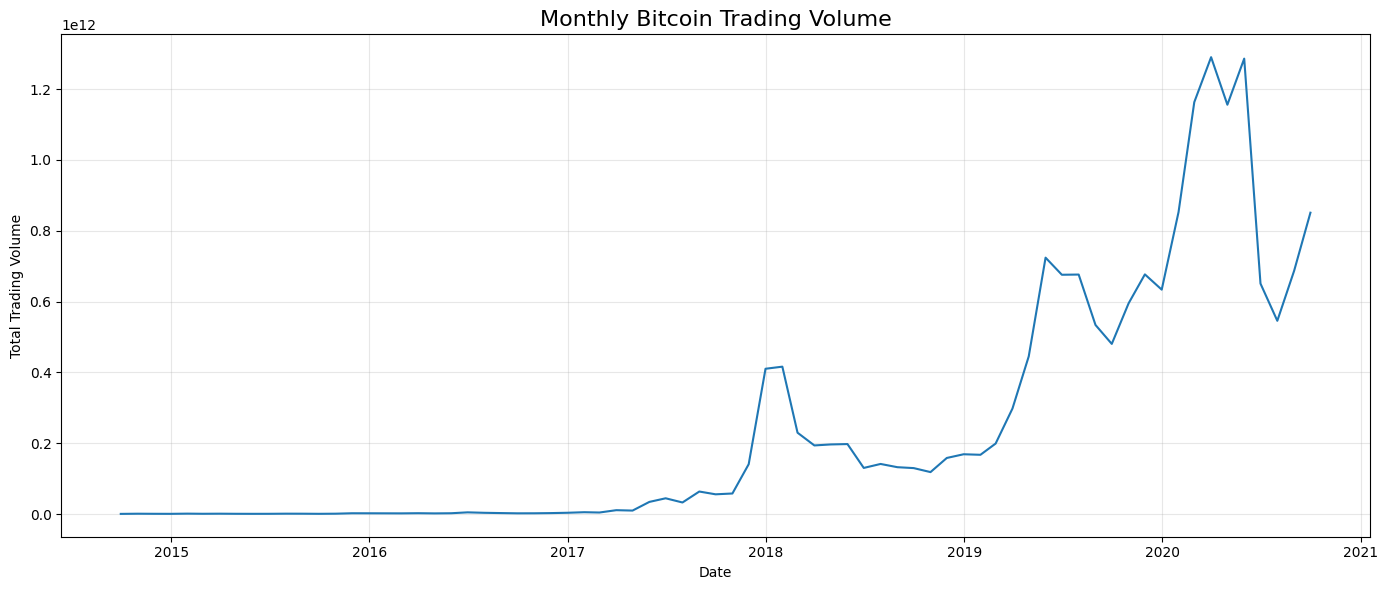

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_monthly['DATE'],
    df_btc_monthly['VOLUME'],
    linewidth=1.5
)

plt.title('Monthly Bitcoin Trading Volume', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Trading Volume')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

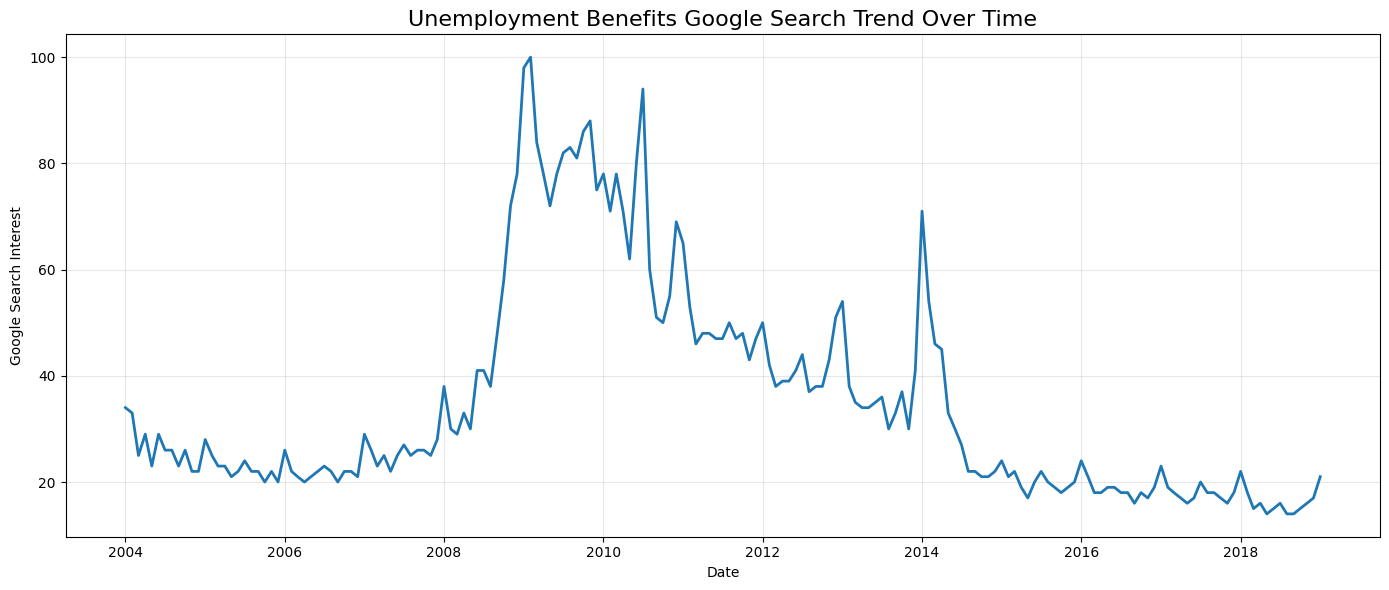

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_unemployment['MONTH'],
    df_unemployment['UE_BENEFITS_WEB_SEARCH'],
    linewidth=2
)

plt.title('Unemployment Benefits Google Search Trend Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Google Search Interest')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

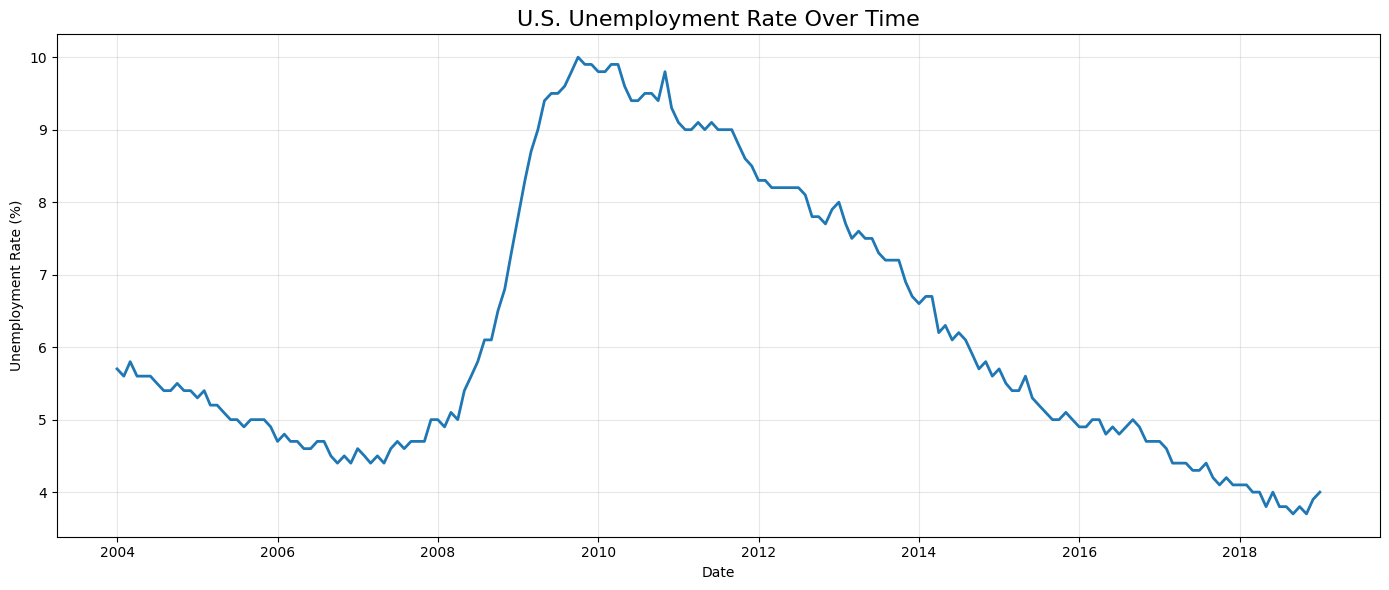

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_unemployment['MONTH'],
    df_unemployment['UNRATE'],
    linewidth=2
)

plt.title('U.S. Unemployment Rate Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

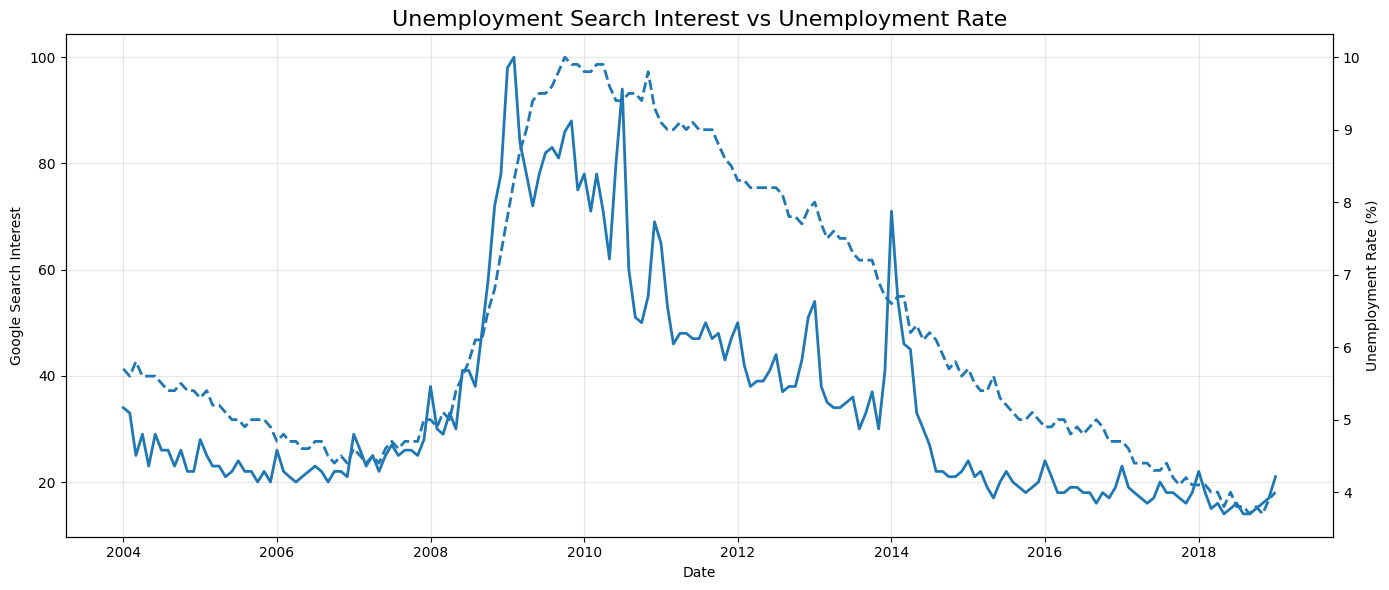

In [30]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_unemployment['MONTH'],
    df_unemployment['UE_BENEFITS_WEB_SEARCH'],
    linewidth=2,
    label='Google Search Interest'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Google Search Interest')

ax2 = ax1.twinx()

ax2.plot(
    df_unemployment['MONTH'],
    df_unemployment['UNRATE'],
    linewidth=2,
    linestyle='--',
    label='Unemployment Rate'
)

ax2.set_ylabel('Unemployment Rate (%)')

plt.title(
    'Unemployment Search Interest vs Unemployment Rate',
    fontsize=16
)

ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
correlation = df_unemployment[
    ['UE_BENEFITS_WEB_SEARCH', 'UNRATE']
].corr()

display(correlation)

,UE_BENEFITS_WEB_SEARCH,UNRATE
UE_BENEFITS_WEB_SEARCH,1.000000,0.852924
UNRATE,0.852924,1.000000


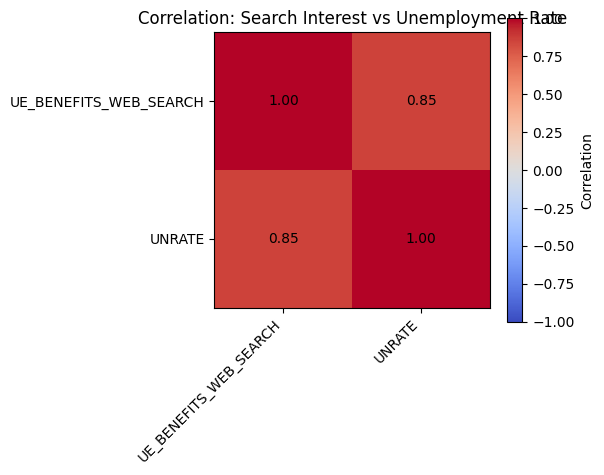

In [32]:
corr = df_unemployment[
    ['UE_BENEFITS_WEB_SEARCH', 'UNRATE']
].corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            f'{corr.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation: Search Interest vs Unemployment Rate')

plt.tight_layout()
plt.show()

In [33]:
top_search_periods = (
    df_unemployment
    .nlargest(10, 'UE_BENEFITS_WEB_SEARCH')
    [['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE']]
)

display(top_search_periods)

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
61,2009-02-01,100,8.3
60,2009-01-01,98,7.8
78,2010-07-01,94,9.4
70,2009-11-01,88,9.9
69,2009-10-01,86,10.0
62,2009-03-01,84,8.7
67,2009-08-01,83,9.6
66,2009-07-01,82,9.5
68,2009-09-01,81,9.8
77,2010-06-01,80,9.4


In [34]:
df_tesla['TSLA_SEARCH_ROLLING_6M'] = (
    df_tesla['TSLA_WEB_SEARCH']
    .rolling(window=6)
    .mean()
)

df_tesla['TSLA_PRICE_ROLLING_6M'] = (
    df_tesla['TSLA_USD_CLOSE']
    .rolling(window=6)
    .mean()
)

print("Tesla rolling averages created.")

Tesla rolling averages created.


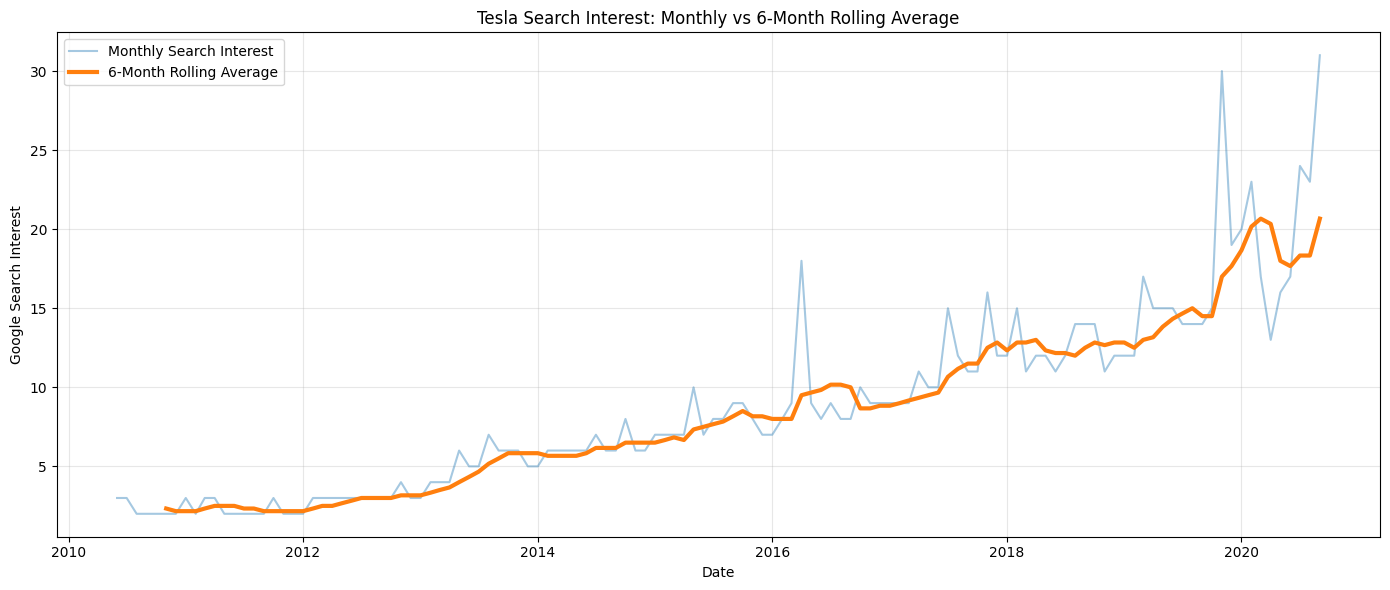

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_WEB_SEARCH'],
    alpha=0.4,
    label='Monthly Search Interest'
)

plt.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_SEARCH_ROLLING_6M'],
    linewidth=3,
    label='6-Month Rolling Average'
)

plt.title('Tesla Search Interest: Monthly vs 6-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Google Search Interest')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
df_btc_price['BTC_PRICE_ROLLING_30D'] = (
    df_btc_price['CLOSE']
    .rolling(window=30)
    .mean()
)

print("Bitcoin 30-day rolling average created.")

Bitcoin 30-day rolling average created.


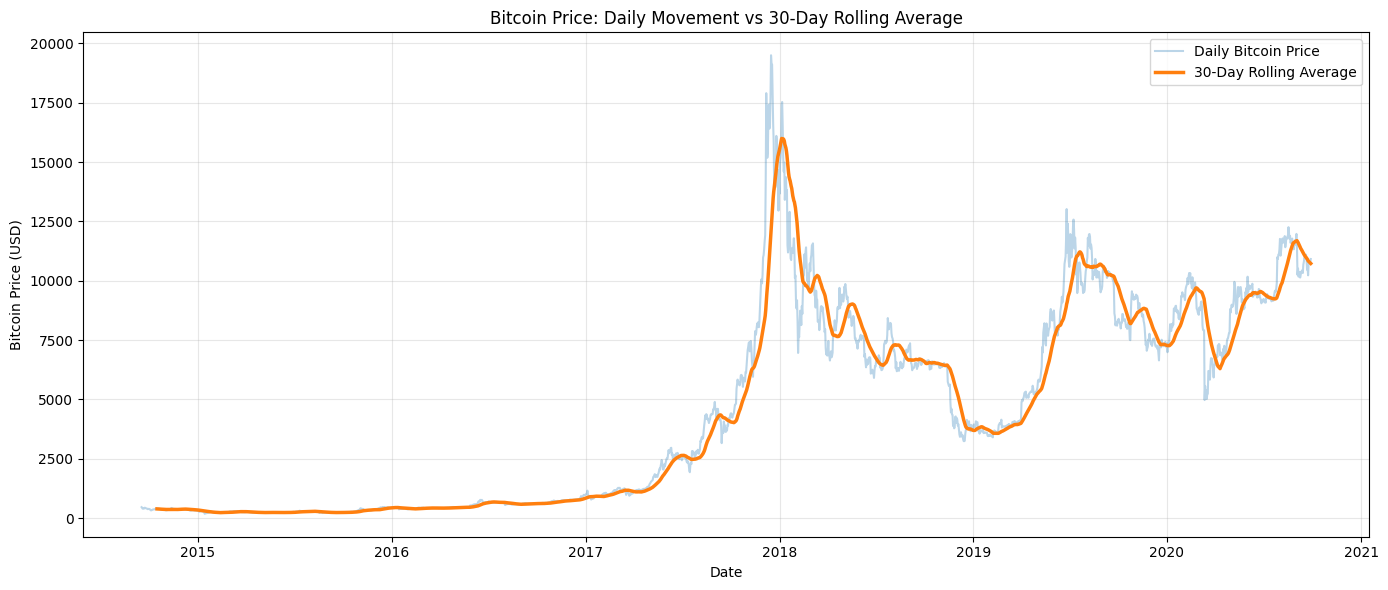

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['CLOSE'],
    alpha=0.3,
    label='Daily Bitcoin Price'
)

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['BTC_PRICE_ROLLING_30D'],
    linewidth=2.5,
    label='30-Day Rolling Average'
)

plt.title('Bitcoin Price: Daily Movement vs 30-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
df_unemployment['SEARCH_ROLLING_6M'] = (
    df_unemployment['UE_BENEFITS_WEB_SEARCH']
    .rolling(window=6)
    .mean()
)

df_unemployment['UNRATE_ROLLING_6M'] = (
    df_unemployment['UNRATE']
    .rolling(window=6)
    .mean()
)

print("Unemployment rolling averages created.")

Unemployment rolling averages created.


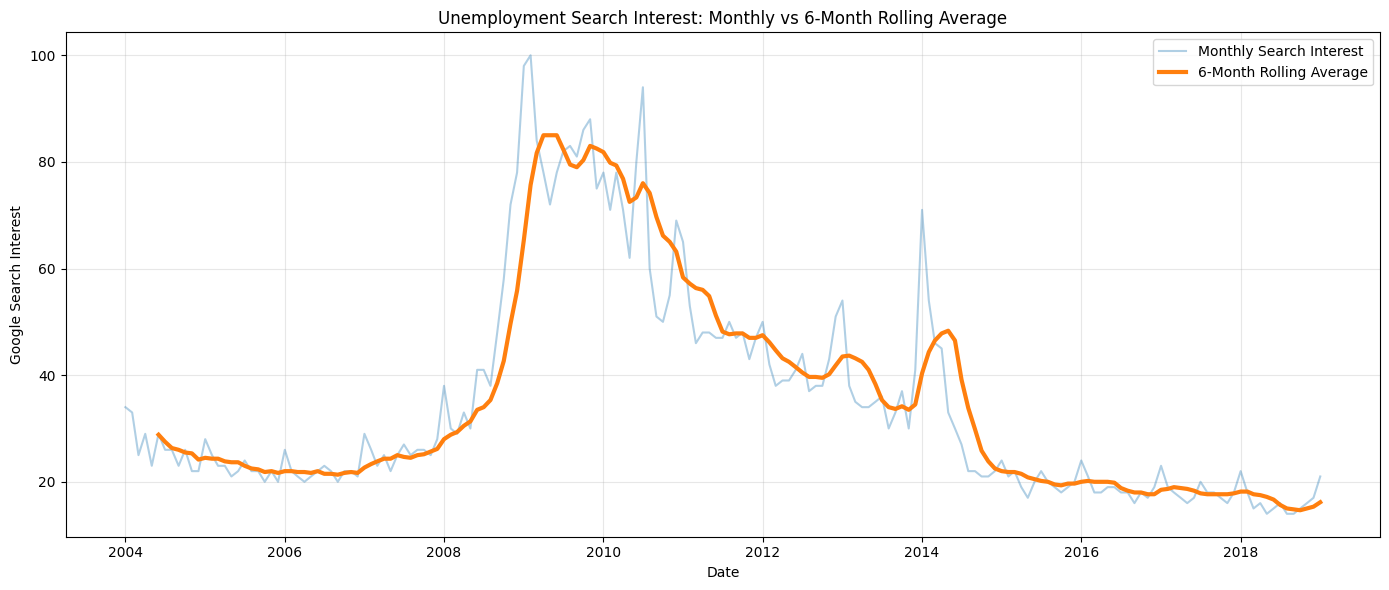

In [39]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_unemployment['MONTH'],
    df_unemployment['UE_BENEFITS_WEB_SEARCH'],
    alpha=0.35,
    label='Monthly Search Interest'
)

plt.plot(
    df_unemployment['MONTH'],
    df_unemployment['SEARCH_ROLLING_6M'],
    linewidth=3,
    label='6-Month Rolling Average'
)

plt.title('Unemployment Search Interest: Monthly vs 6-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Google Search Interest')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
df_tesla['TSLA_PRICE_PCT_CHANGE'] = (
    df_tesla['TSLA_USD_CLOSE']
    .pct_change() * 100
)

display(
    df_tesla[
        ['MONTH', 'TSLA_USD_CLOSE', 'TSLA_PRICE_PCT_CHANGE']
    ].head(10)
)

,MONTH,TSLA_USD_CLOSE,TSLA_PRICE_PCT_CHANGE
0,2010-06-01,4.766,NaN
1,2010-07-01,3.988,-16.323961
2,2010-08-01,3.896,-2.306921
3,2010-09-01,4.082,4.774127
4,2010-10-01,4.368,7.006369
5,2010-11-01,7.066,61.767399
6,2010-12-01,5.326,-24.624965
7,2011-01-01,4.820,-9.500563
8,2011-02-01,4.778,-0.871369
9,2011-03-01,5.550,16.157388


In [41]:
df_btc_price['BTC_PRICE_PCT_CHANGE'] = (
    df_btc_price['CLOSE']
    .pct_change() * 100
)

display(
    df_btc_price[
        ['DATE', 'CLOSE', 'BTC_PRICE_PCT_CHANGE']
    ].head(10)
)

,DATE,CLOSE,BTC_PRICE_PCT_CHANGE
0,2014-09-17,457.334015,NaN
1,2014-09-18,424.440002,-7.192558
2,2014-09-19,394.795990,-6.984264
3,2014-09-20,408.903992,3.573492
4,2014-09-21,398.821014,-2.465855
5,2014-09-22,402.152008,0.835210
6,2014-09-23,435.790985,8.364742
7,2014-09-24,423.204987,-2.888081
8,2014-09-25,411.574005,-2.748309
9,2014-09-26,404.424988,-1.736994


In [42]:
largest_btc_increases = (
    df_btc_price
    .nlargest(10, 'BTC_PRICE_PCT_CHANGE')
    [['DATE', 'CLOSE', 'BTC_PRICE_PCT_CHANGE']]
)

display(largest_btc_increases)

,DATE,CLOSE,BTC_PRICE_PCT_CHANGE
1177,2017-12-07,17899.699219,25.247169
1037,2017-07-20,2817.600098,23.936087
1176,2017-12-06,14291.500000,19.928334
2010,2020-03-19,6191.192871,18.187756
120,2015-01-15,209.843994,17.821709
1658,2019-04-02,4879.877930,17.356014
1864,2019-10-25,8660.700195,15.576342
1034,2017-07-17,2228.409912,15.472426
1094,2017-09-15,3637.520020,15.295649
56,2014-11-12,423.561005,15.193570


In [43]:
largest_btc_decreases = (
    df_btc_price
    .nsmallest(10, 'BTC_PRICE_PCT_CHANGE')
    [['DATE', 'CLOSE', 'BTC_PRICE_PCT_CHANGE']]
)

display(largest_btc_decreases)

,DATE,CLOSE,BTC_PRICE_PCT_CHANGE
2003,2020-03-12,4970.788086,-37.169539
119,2015-01-14,178.102997,-21.144862
1093,2017-09-14,3154.949951,-18.741101
335,2015-08-18,211.078995,-18.178829
1217,2018-01-16,11490.500000,-16.854801
1237,2018-02-05,6955.270020,-15.968807
118,2015-01-13,225.860992,-15.659308
485,2016-01-15,364.330994,-15.332114
847,2017-01-11,777.757019,-14.313650
1744,2019-06-27,11182.806641,-14.085681


In [44]:
tesla_corr = df_tesla[
    ['TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE']
].corr()

display(tesla_corr)

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
TSLA_WEB_SEARCH,1.000000,0.735004
TSLA_USD_CLOSE,0.735004,1.000000


In [45]:
tesla_correlation = df_tesla[
    'TSLA_WEB_SEARCH'
].corr(
    df_tesla['TSLA_USD_CLOSE']
)

print(f"Tesla Search vs Stock Price Correlation: {tesla_correlation:.3f}")

Tesla Search vs Stock Price Correlation: 0.735


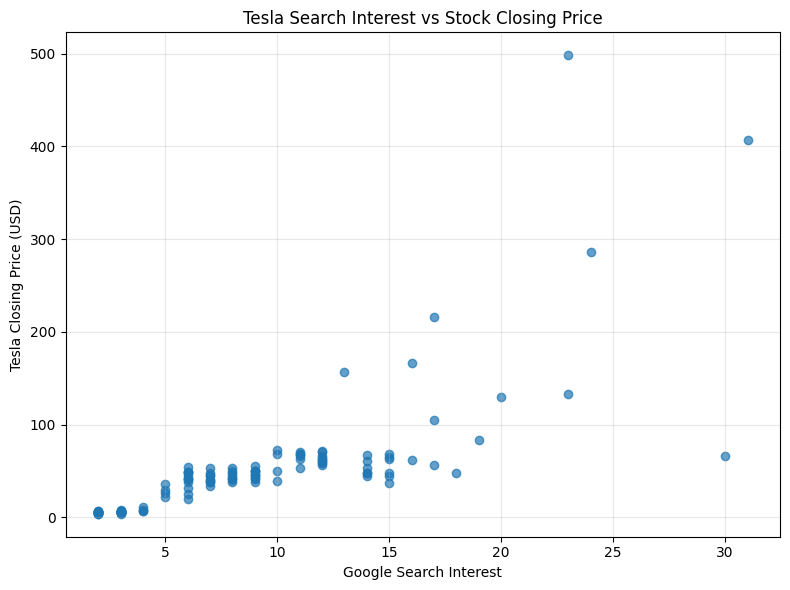

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_tesla['TSLA_WEB_SEARCH'],
    df_tesla['TSLA_USD_CLOSE'],
    alpha=0.7
)

plt.title('Tesla Search Interest vs Stock Closing Price')
plt.xlabel('Google Search Interest')
plt.ylabel('Tesla Closing Price (USD)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
unemployment_correlation = df_unemployment[
    'UE_BENEFITS_WEB_SEARCH'
].corr(
    df_unemployment['UNRATE']
)

print(
    f"Unemployment Search vs Unemployment Rate Correlation: "
    f"{unemployment_correlation:.3f}"
)

Unemployment Search vs Unemployment Rate Correlation: 0.853


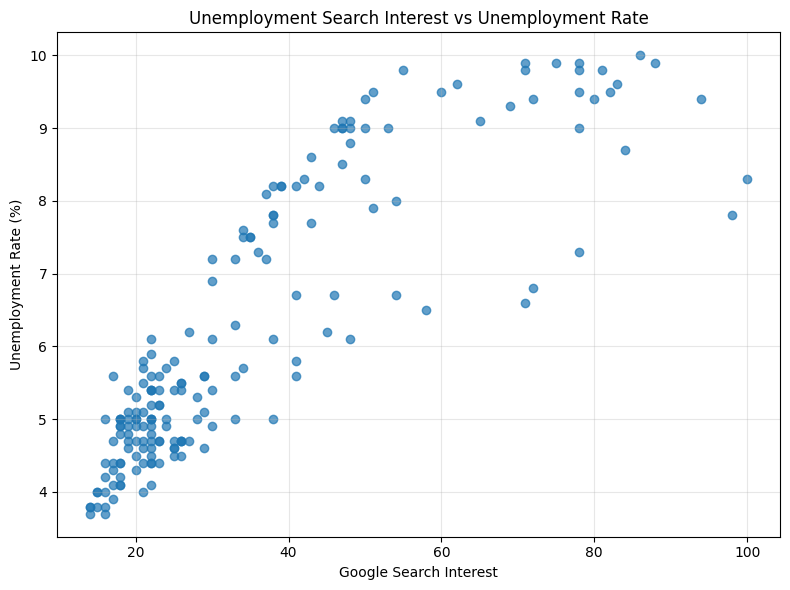

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_unemployment['UE_BENEFITS_WEB_SEARCH'],
    df_unemployment['UNRATE'],
    alpha=0.7
)

plt.title('Unemployment Search Interest vs Unemployment Rate')
plt.xlabel('Google Search Interest')
plt.ylabel('Unemployment Rate (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
def interpret_correlation(value):
    strength = abs(value)

    if strength >= 0.8:
        level = "Very strong"
    elif strength >= 0.6:
        level = "Strong"
    elif strength >= 0.4:
        level = "Moderate"
    elif strength >= 0.2:
        level = "Weak"
    else:
        level = "Very weak"

    if value > 0:
        direction = "positive"
    elif value < 0:
        direction = "negative"
    else:
        direction = "no"

    return f"{level} {direction} relationship"

In [51]:
print(
    "Tesla:",
    interpret_correlation(tesla_correlation)
)

print(
    "Unemployment:",
    interpret_correlation(unemployment_correlation)
)

Tesla: Strong positive relationship
Unemployment: Very strong positive relationship


In [52]:
correlation_summary = pd.DataFrame({
    'Analysis': [
        'Tesla Search Interest vs Tesla Stock Price',
        'Unemployment Search Interest vs Unemployment Rate'
    ],
    'Correlation': [
        tesla_correlation,
        unemployment_correlation
    ]
})

correlation_summary['Absolute Correlation'] = (
    correlation_summary['Correlation'].abs()
)

correlation_summary['Interpretation'] = (
    correlation_summary['Correlation']
    .apply(interpret_correlation)
)

display(correlation_summary)

,Analysis,Correlation,Absolute Correlation,Interpretation
0,Tesla Search Interest vs Tesla Stock Price,0.735004,0.735004,Strong positive relationship
1,Unemployment Search Interest vs Unemployment Rate,0.852924,0.852924,Very strong positive relationship


In [53]:
btc_stats = {
    'Average Price': df_btc_price['CLOSE'].mean(),
    'Minimum Price': df_btc_price['CLOSE'].min(),
    'Maximum Price': df_btc_price['CLOSE'].max(),
    'Average Daily Volume': df_btc_price['VOLUME'].mean(),
    'Average Daily % Change': df_btc_price['BTC_PRICE_PCT_CHANGE'].mean(),
    'Daily Volatility': df_btc_price['BTC_PRICE_PCT_CHANGE'].std()
}

btc_summary = pd.DataFrame(
    btc_stats.items(),
    columns=['Metric', 'Value']
)

display(btc_summary)

,Metric,Value
0,Average Price,4.429421e+03
1,Minimum Price,1.781030e+02
2,Maximum Price,1.949740e+04
3,Average Daily Volume,8.043622e+09
4,Average Daily % Change,2.200534e-01
5,Daily Volatility,3.872005e+00


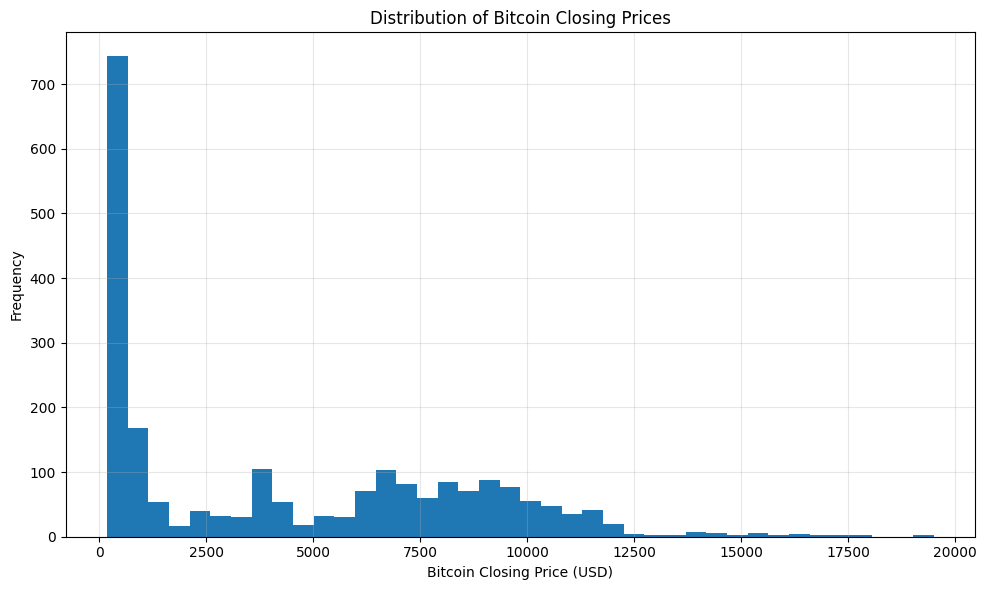

In [54]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_btc_price['CLOSE'],
    bins=40
)

plt.title('Distribution of Bitcoin Closing Prices')
plt.xlabel('Bitcoin Closing Price (USD)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

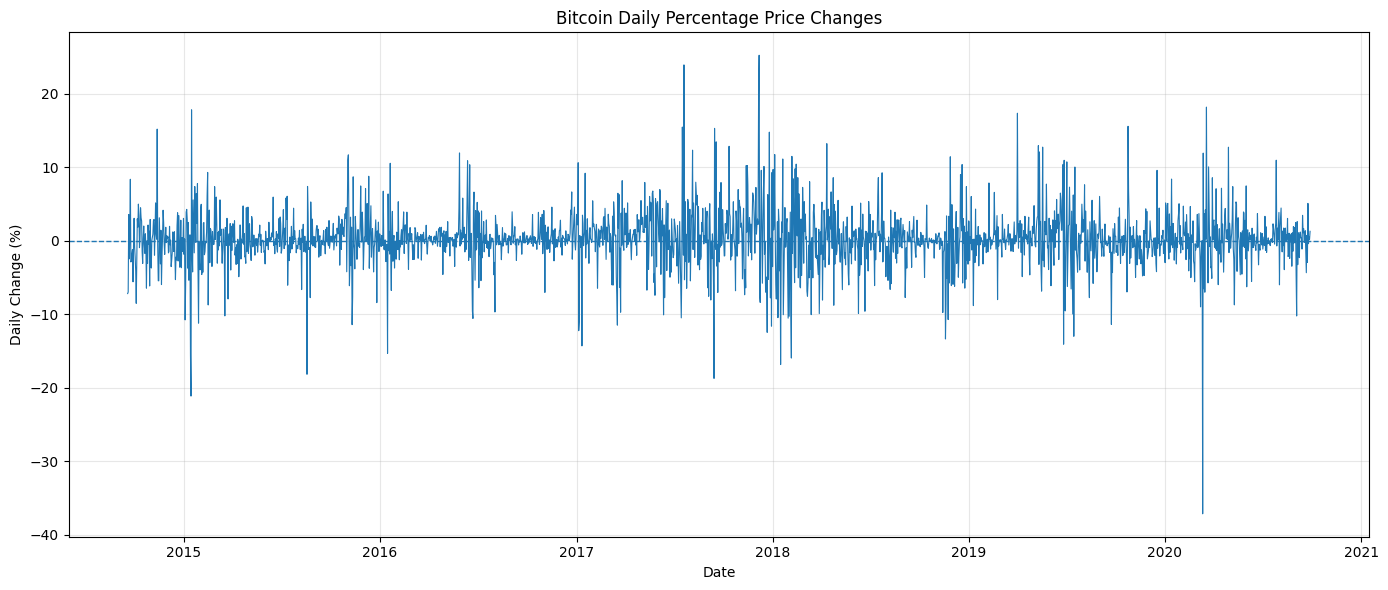

In [55]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['BTC_PRICE_PCT_CHANGE'],
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.title('Bitcoin Daily Percentage Price Changes')
plt.xlabel('Date')
plt.ylabel('Daily Change (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

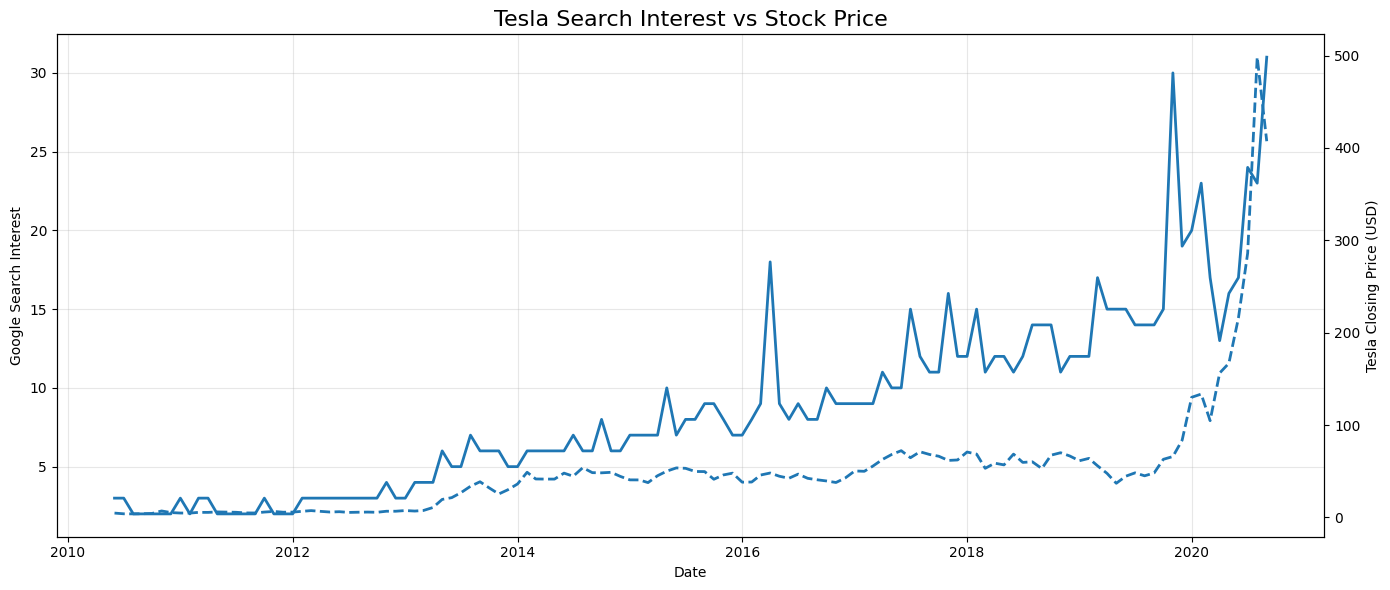

In [56]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_WEB_SEARCH'],
    linewidth=2,
    label='Tesla Search Interest'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Google Search Interest')

ax2 = ax1.twinx()

ax2.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_USD_CLOSE'],
    linewidth=2,
    linestyle='--',
    label='Tesla Stock Price'
)

ax2.set_ylabel('Tesla Closing Price (USD)')

plt.title(
    'Tesla Search Interest vs Stock Price',
    fontsize=16
)

ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

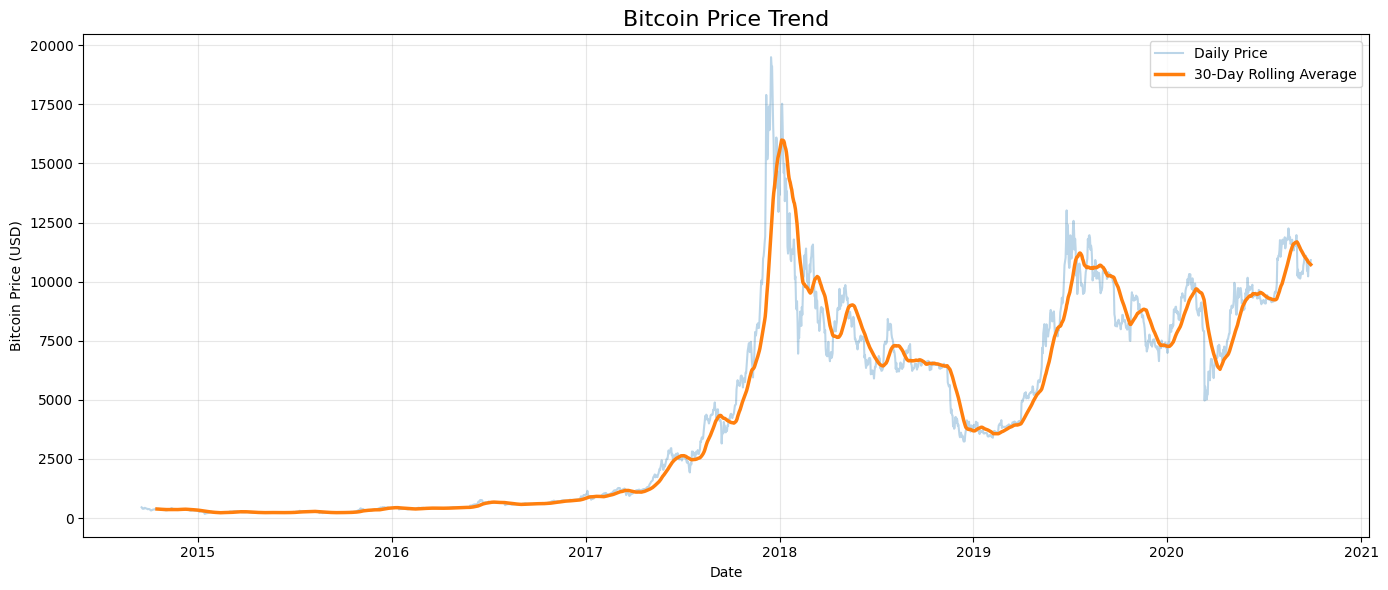

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['CLOSE'],
    alpha=0.3,
    label='Daily Price'
)

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['BTC_PRICE_ROLLING_30D'],
    linewidth=2.5,
    label='30-Day Rolling Average'
)

plt.title(
    'Bitcoin Price Trend',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

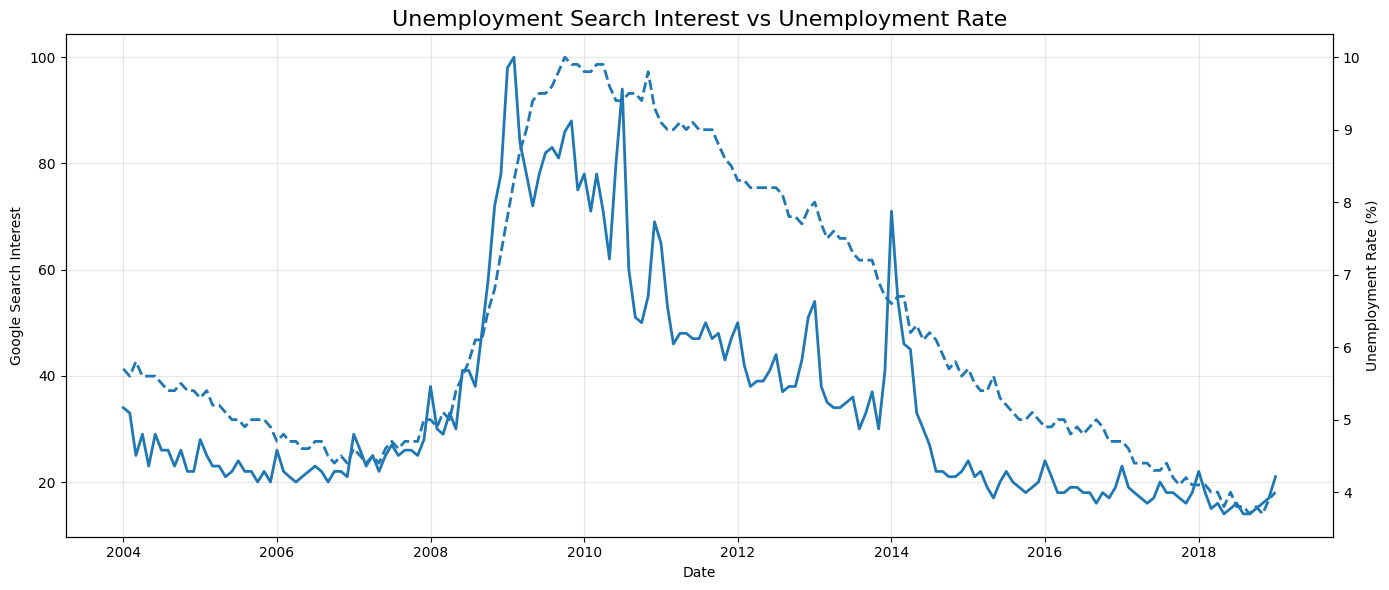

In [58]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_unemployment['MONTH'],
    df_unemployment['UE_BENEFITS_WEB_SEARCH'],
    linewidth=2,
    label='Search Interest'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Google Search Interest')

ax2 = ax1.twinx()

ax2.plot(
    df_unemployment['MONTH'],
    df_unemployment['UNRATE'],
    linewidth=2,
    linestyle='--',
    label='Unemployment Rate'
)

ax2.set_ylabel('Unemployment Rate (%)')

plt.title(
    'Unemployment Search Interest vs Unemployment Rate',
    fontsize=16
)

ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

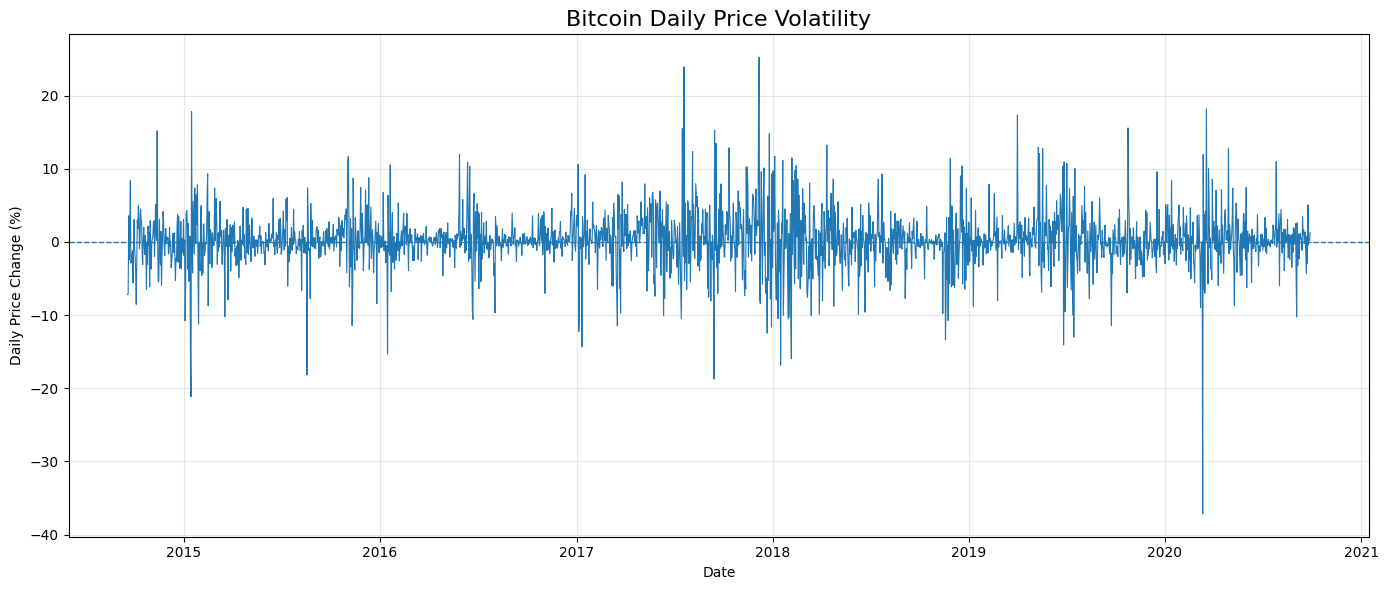

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_btc_price['DATE'],
    df_btc_price['BTC_PRICE_PCT_CHANGE'],
    linewidth=0.8
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title(
    'Bitcoin Daily Price Volatility',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Daily Price Change (%)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
project_metrics = pd.DataFrame({
    'Metric': [
        'Tesla Search vs Stock Correlation',
        'Unemployment Search vs Unemployment Rate Correlation',
        'Bitcoin Average Price',
        'Bitcoin Maximum Price',
        'Bitcoin Minimum Price',
        'Bitcoin Daily Return Volatility'
    ],
    'Value': [
        tesla_correlation,
        unemployment_correlation,
        df_btc_price['CLOSE'].mean(),
        df_btc_price['CLOSE'].max(),
        df_btc_price['CLOSE'].min(),
        df_btc_price['BTC_PRICE_PCT_CHANGE'].std()
    ]
})

display(project_metrics)

,Metric,Value
0,Tesla Search vs Stock Correlation,0.735004
1,Unemployment Search vs Unemployment Rate Corre...,0.852924
2,Bitcoin Average Price,4429.421245
3,Bitcoin Maximum Price,19497.400391
4,Bitcoin Minimum Price,178.102997
5,Bitcoin Daily Return Volatility,3.872005


In [61]:
top_tesla_search = (
    df_tesla
    .nlargest(10, 'TSLA_WEB_SEARCH')
    [['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE']]
)

display(top_tesla_search)

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
123,2020-09-01,31,407.339996
113,2019-11-01,30,65.987999
121,2020-07-01,24,286.152008
116,2020-02-01,23,133.598007
122,2020-08-01,23,498.320007
115,2020-01-01,20,130.113998
114,2019-12-01,19,83.666000
70,2016-04-01,18,48.152000
105,2019-03-01,17,55.972000
117,2020-03-01,17,104.800003


In [62]:
top_tesla_price = (
    df_tesla
    .nlargest(10, 'TSLA_USD_CLOSE')
    [['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE']]
)

display(top_tesla_price)

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
122,2020-08-01,23,498.320007
123,2020-09-01,31,407.339996
121,2020-07-01,24,286.152008
120,2020-06-01,17,215.962006
119,2020-05-01,16,167.000000
118,2020-04-01,13,156.376007
116,2020-02-01,23,133.598007
115,2020-01-01,20,130.113998
117,2020-03-01,17,104.800003
114,2019-12-01,19,83.666000


In [63]:
top_btc_price = (
    df_btc_price
    .nlargest(10, 'CLOSE')
    [['DATE', 'CLOSE', 'BTC_PRICE_PCT_CHANGE']]
)

display(top_btc_price)

,DATE,CLOSE,BTC_PRICE_PCT_CHANGE
1186,2017-12-16,19497.400391,10.111877
1187,2017-12-17,19140.800781,-1.828960
1188,2017-12-18,19114.199219,-0.138978
1177,2017-12-07,17899.699219,25.247169
1189,2017-12-19,17776.699219,-6.997416
1185,2017-12-15,17706.900391,6.899906
1207,2018-01-06,17527.000000,0.559396
1206,2018-01-05,17429.500000,11.733293
1182,2017-12-12,17415.400391,2.825797
1181,2017-12-11,16936.800781,9.585002


In [64]:
top_unemployment_search = (
    df_unemployment
    .nlargest(10, 'UE_BENEFITS_WEB_SEARCH')
    [['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE']]
)

display(top_unemployment_search)

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
61,2009-02-01,100,8.3
60,2009-01-01,98,7.8
78,2010-07-01,94,9.4
70,2009-11-01,88,9.9
69,2009-10-01,86,10.0
62,2009-03-01,84,8.7
67,2009-08-01,83,9.6
66,2009-07-01,82,9.5
68,2009-09-01,81,9.8
77,2010-06-01,80,9.4


In [65]:
print("===== PROJECT INSIGHTS =====\n")

print(
    f"1. Tesla search interest and stock price correlation: "
    f"{tesla_correlation:.3f}"
)

print(
    f"2. Unemployment search interest and unemployment rate correlation: "
    f"{unemployment_correlation:.3f}"
)

print(
    f"3. Bitcoin average closing price: "
    f"${df_btc_price['CLOSE'].mean():,.2f}"
)

print(
    f"4. Bitcoin maximum closing price: "
    f"${df_btc_price['CLOSE'].max():,.2f}"
)

print(
    f"5. Bitcoin minimum closing price: "
    f"${df_btc_price['CLOSE'].min():,.2f}"
)

print(
    f"6. Bitcoin daily return volatility: "
    f"{df_btc_price['BTC_PRICE_PCT_CHANGE'].std():.2f}%"
)

===== PROJECT INSIGHTS =====

1. Tesla search interest and stock price correlation: 0.735
2. Unemployment search interest and unemployment rate correlation: 0.853
3. Bitcoin average closing price: $4,429.42
4. Bitcoin maximum closing price: $19,497.40
5. Bitcoin minimum closing price: $178.10
6. Bitcoin daily return volatility: 3.87%


# Conclusion

This project analyzed Google search trends alongside financial and economic indicators using Python.

### Key Areas Analyzed

- Tesla Google search interest and Tesla stock closing price
- Bitcoin daily price and trading volume
- Unemployment-benefit search interest and the U.S. unemployment rate

### Analytical Techniques

- Data cleaning and validation
- Date-time transformation
- Exploratory data analysis
- Time-series visualization
- Rolling-average analysis
- Percentage-change analysis
- Correlation analysis
- Volatility analysis

### Key Findings

The analysis identified measurable relationships and trends between the selected search, financial, and economic indicators. Correlation and time-series analysis were used to quantify these relationships while avoiding causal conclusions.

### Limitations

- Google Trends represents relative search interest rather than absolute search volume.
- Correlation does not establish causation.
- The datasets cover different time periods and frequencies.
- Bitcoin analysis in this project focuses on price and trading volume rather than Bitcoin search interest.

### Tools

Python, Pandas, NumPy, Matplotlib, Google Trends data, financial market data.